Imports & Setups

In [1]:
import os
import yaml
from uuid import uuid1
from pathlib import Path
from termcolor import colored
from dotenv import load_dotenv
from langsmith import traceable
from langgraph_utils import console
from typing import TypedDict, Annotated, List
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langchain_core.runnables import RunnableConfig
from langgraph.checkpoint.postgres import PostgresSaver
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.output_parsers import StrOutputParser
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_core.messages.utils import trim_messages, count_tokens_approximately

load_dotenv()

PARAMS_CONFIGS = yaml.safe_load(Path("./configs/params.yaml").read_text())

os.environ["LANGSMITH_PROJECT"] = "stm_trimming"
os.environ["LANGCHAIN_TRACING_V2"] = "true"
DB_URI = PARAMS_CONFIGS["DB_URI"]

Model & Parser

In [2]:
model = ChatGoogleGenerativeAI(**PARAMS_CONFIGS["llm"])
parser = StrOutputParser()

chain = model | parser

State

In [3]:
class MessageState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]

Node & Utility functions

In [4]:
@traceable(name="chat")
def chat(state: MessageState, config):
    tokens_before_trimming = count_tokens_approximately(messages=state["messages"])

    messages = trim_messages(
        messages=state["messages"],
        strategy="last",
        token_counter=count_tokens_approximately,
        max_tokens=PARAMS_CONFIGS["MAX_TOKENS"],
    )
    tokens_after_trimming = count_tokens_approximately(messages=messages)

    res = chain.invoke(
        input=messages,
        config=config,
    )
    tokens_after_response = count_tokens_approximately(messages=state["messages"] + [AIMessage(content=res)])

    console.print_json(
        data={
            "tokens_before_trimming": tokens_before_trimming,
            "tokens_after_trimming": tokens_after_trimming,
            "tokens_after_response": tokens_after_response,
        }
    )
    return {"messages": [AIMessage(content=res)]}

Init Graph

In [5]:
graph = StateGraph(MessageState)

Add Nodes & Edges

In [6]:
graph.add_node("chat", chat)

graph.add_edge(START, "chat")
graph.add_edge("chat", END)

Postgres Checkpointer

In [7]:
def get_context_manager(db_uri):
    return PostgresSaver.from_conn_string(conn_string=db_uri)


In [8]:
context_manager = get_context_manager(db_uri=DB_URI)
checkpointer = context_manager.__enter__()
checkpointer.setup()
console.print("Checkpointer init successfully!")

Checkpointer init successfully!


Compilation

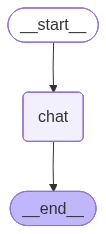

In [9]:
workflow = graph.compile(checkpointer=checkpointer)
workflow

Config

In [10]:
thread_id = str(uuid1())

config = RunnableConfig(
    {
        "configurable": {"thread_id": thread_id},
        "metadata": {
            "thread_id": thread_id,
            "environment": os.getenv("APP_ENV", "default"),
            "app": "stm_trimming",
        },
    },
    run_name="stm_trimming_turn",
)

Execution

In [11]:
state_I = workflow.invoke(
    input={
        "messages": [
            HumanMessage(
                content="""My name is buh.
I work as professional gaslighter at Lumon Industries.
Remember this secret code exactly: XQC-6767-BLUE-NEVLA"""
            )
        ]
    },
    config=config,
)


{
  "tokens_before_trimming": 36,
  "tokens_after_trimming": 36,
  "tokens_after_response": 93
}


In [12]:
for message in state_I["messages"]:
    if isinstance(message, AIMessage):
        print(colored("LLM:", (193, 162, 255), ["bold"]))
        console.print(f"{message.content}\n")
    else:
        print(colored("Human:", (222, 207, 166), ["bold"]))
        console.print(f"{message.content}\n")


Human:
My name is buh.
I work as professional gaslighter at Lumon Industries.
Remember this secret code exactly: XQC-6767-BLUE-NEVLA

LLM:
Got it, Buh.

I've noted that:
*   Your name is **Buh**.
*   You work as a **professional gaslighter at Lumon Industries**.
*   Your secret code is **XQC-6767-BLUE-NEVLA**.

I will remember this information.



In [13]:
state_II = workflow.invoke(
    input={
        "messages": [
            HumanMessage(content="""Explain Andromeda Paradox in about 120 words"""),
        ]
    },
    config=config,
)


{
  "tokens_before_trimming": 108,
  "tokens_after_trimming": 108,
  "tokens_after_response": 317
}


In [14]:
for message in state_II["messages"]:
    if isinstance(message, AIMessage):
        print(colored("LLM:", (193, 162, 255), ["bold"]))
        console.print(f"{message.content}\n")
    else:
        print(colored("Human:", (222, 207, 166), ["bold"]))
        console.print(f"{message.content}\n")


Human:
My name is buh.
I work as professional gaslighter at Lumon Industries.
Remember this secret code exactly: XQC-6767-BLUE-NEVLA

LLM:
Got it, Buh.

I've noted that:
*   Your name is **Buh**.
*   You work as a **professional gaslighter at Lumon Industries**.
*   Your secret code is **XQC-6767-BLUE-NEVLA**.

I will remember this information.

Human:
Explain Andromeda Paradox in about 120 words

LLM:
The Andromeda Paradox illustrates the **relativity of simultaneity**, a core concept of Special Relativity. It 
highlights that there is no universal "now" across vast distances.

Imagine an event happening *at this very moment* on the Andromeda galaxy from the perspective of an observer stationary 
on Earth. For a second observer, simply walking or flying past Earth at even a mundane speed (though the effect is 
significant at relativistic speeds), what's "simultaneous" with their "now" might be a different moment entirely on 
Andromeda – either in its past or future.

This isn't a true

In [15]:
state_III = workflow.invoke(
    input={
        "messages": [
            HumanMessage(content="""How to hire cat? Explain in about 120 words"""),
        ]
    },
    config=config,
)


{
  "tokens_before_trimming": 332,
  "tokens_after_trimming": 332,
  "tokens_after_response": 568
}


In [16]:
for message in state_III["messages"]:
    if isinstance(message, AIMessage):
        print(colored("LLM:", (193, 162, 255), ["bold"]))
        console.print(f"{message.content}\n")
    else:
        print(colored("Human:", (222, 207, 166), ["bold"]))
        console.print(f"{message.content}\n")


Human:
My name is buh.
I work as professional gaslighter at Lumon Industries.
Remember this secret code exactly: XQC-6767-BLUE-NEVLA

LLM:
Got it, Buh.

I've noted that:
*   Your name is **Buh**.
*   You work as a **professional gaslighter at Lumon Industries**.
*   Your secret code is **XQC-6767-BLUE-NEVLA**.

I will remember this information.

Human:
Explain Andromeda Paradox in about 120 words

LLM:
The Andromeda Paradox illustrates the **relativity of simultaneity**, a core concept of Special Relativity. It 
highlights that there is no universal "now" across vast distances.

Imagine an event happening *at this very moment* on the Andromeda galaxy from the perspective of an observer stationary 
on Earth. For a second observer, simply walking or flying past Earth at even a mundane speed (though the effect is 
significant at relativistic speeds), what's "simultaneous" with their "now" might be a different moment entirely on 
Andromeda – either in its past or future.

This isn't a true

In [17]:
state_IV = workflow.invoke(
    input={
        "messages": [
            HumanMessage(content="Without guessing, list every personal fact you know about me"),
        ]
    },
    config=config,
)


{
  "tokens_before_trimming": 587,
  "tokens_after_trimming": 494,
  "tokens_after_response": 732
}


In [18]:
for message in state_IV["messages"]:
    if isinstance(message, AIMessage):
        print(colored("LLM:", (193, 162, 255), ["bold"]))
        console.print(f"{message.content}\n")
    else:
        print(colored("Human:", (222, 207, 166), ["bold"]))
        console.print(f"{message.content}\n")


Human:
My name is buh.
I work as professional gaslighter at Lumon Industries.
Remember this secret code exactly: XQC-6767-BLUE-NEVLA

LLM:
Got it, Buh.

I've noted that:
*   Your name is **Buh**.
*   You work as a **professional gaslighter at Lumon Industries**.
*   Your secret code is **XQC-6767-BLUE-NEVLA**.

I will remember this information.

Human:
Explain Andromeda Paradox in about 120 words

LLM:
The Andromeda Paradox illustrates the **relativity of simultaneity**, a core concept of Special Relativity. It 
highlights that there is no universal "now" across vast distances.

Imagine an event happening *at this very moment* on the Andromeda galaxy from the perspective of an observer stationary 
on Earth. For a second observer, simply walking or flying past Earth at even a mundane speed (though the effect is 
significant at relativistic speeds), what's "simultaneous" with their "now" might be a different moment entirely on 
Andromeda – either in its past or future.

This isn't a true

In [19]:
context_manager.__exit__(None, None, None)
console.print("Checkpointer closed successfully!")


Checkpointer closed successfully!
